In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
#Loading the dataset

In [8]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional-full.csv to bank-additional-full (1).csv


In [13]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [14]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [16]:
# Check missing values

In [17]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [18]:
df = df.replace('unknown', pd.NA)

In [19]:
# Convert target variable

In [20]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [ ]:
#Define Funnel Metrics : Total Contacts, Total Conversions (customers) ,Conversion Rat

In [21]:
total_contacts = len(df)
total_customers = df['y'].sum()

conversion_rate = total_customers / total_contacts

print("Total Contacts:", total_contacts)
print("Total Customers:", total_customers)
print("Overall Conversion Rate:", round(conversion_rate * 100, 2), "%")

Total Contacts: 41188
Total Customers: 4640
Overall Conversion Rate: 11.27 %


In [ ]:
#Funnel by Channel - This answers: Which channels bring high-quality leads?

In [22]:
channel_funnel = df.groupby('contact')['y'].agg(['count', 'sum'])
channel_funnel.columns = ['Total_Contacts', 'Conversions']

channel_funnel['Conversion_Rate'] = channel_funnel['Conversions'] / channel_funnel['Total_Contacts']

channel_funnel.sort_values(by='Conversion_Rate', ascending=False)

,Total_Contacts,Conversions,Conversion_Rate
contact,,,
cellular,26144,3853,0.147376
telephone,15044,787,0.052313


In [23]:
#Funnel by Campaign

In [24]:
campaign_funnel = df.groupby('campaign')['y'].agg(['count', 'sum'])
campaign_funnel.columns = ['Contacts', 'Conversions']

campaign_funnel['Conversion_Rate'] = campaign_funnel['Conversions'] / campaign_funnel['Contacts']

campaign_funnel.head()

,Contacts,Conversions,Conversion_Rate
campaign,,,
1,17642,2300,0.130371
2,10570,1211,0.114570
3,5341,574,0.107471
4,2651,249,0.093927
5,1599,120,0.075047


In [25]:
#Drop-off Analysis -We simulate drop-off:

#Stage 1 → Contacts
#Stage 2 → Interested (use poutcome, duration, or previous)
#Stage 3 → Converted

In [26]:
# Create engagement stage
df['engaged'] = df['duration'].apply(lambda x: 1 if x > df['duration'].median() else 0)

# Funnel counts
stage1 = len(df)
stage2 = df['engaged'].sum()
stage3 = df['y'].sum()

print("Contacts:", stage1)
print("Engaged:", stage2)
print("Converted:", stage3)

Contacts: 41188
Engaged: 20483
Converted: 4640


In [27]:
#Visualization

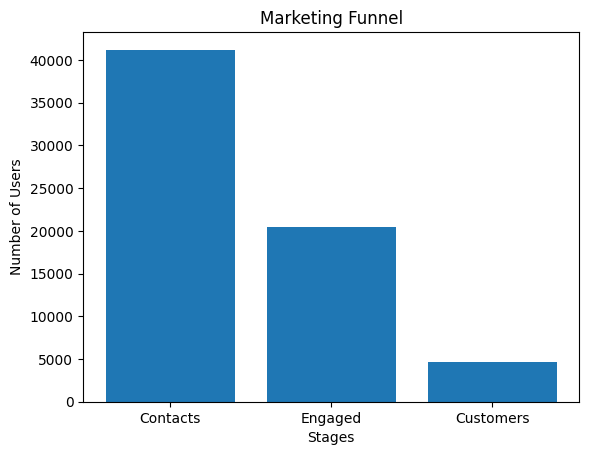

In [30]:
# Funnel values
stages = ['Contacts', 'Engaged', 'Customers']
values = [stage1, stage2, stage3]

plt.figure()
plt.bar(stages, values)
plt.title("Marketing Funnel")
plt.xlabel("Stages")
plt.ylabel("Number of Users")
plt.show()